In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load and prepare the data
df = pd.read_csv('hisar_dataset.csv')

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

Dataset Shape: (2875, 31)

First few rows:
   INDEX  YEAR  WEEK No. (1-52)  DATE  MONTH  .DBT1  .WBT1  .DBT2  .WBT2  \
0  42132  2015                1     1      1    8.0    8.0   21.0   15.4   
1  42132  2015                1     2      1   11.2   11.0   15.8   15.4   
2  42132  2015                1     3      1   12.0   12.0   16.0   14.4   
3  42132  2015                1     4      1    8.4    7.0   13.6   12.6   
4  42132  2015                1     5      1    8.4    8.4   15.8   13.8   

   Max temperature   ...  Relative Humidity for hour2  Mean Wind Speed  \
0              14.0  ...                         52.0              4.8   
1              21.0  ...                         96.0              2.1   
2              16.5  ...                         83.0              4.0   
3              16.0  ...                         89.0              1.2   
4              14.2  ...                         79.0              3.2   

   Wind Direction for hour-1  Wind Direction for hour-2

In [2]:
# Step 1: Data Preparation and Cleaning

df['Rain_Occurred'] = (df['Rain in past (MM)'] > 0).astype(int)

print("Rainfall Statistics:")
print(f"Total days: {len(df)}")
print(f"Rainy days: {df['Rain_Occurred'].sum()} ({df['Rain_Occurred'].mean()*100:.1f}%)")
print(f"Dry days: {len(df) - df['Rain_Occurred'].sum()} ({(1-df['Rain_Occurred'].mean())*100:.1f}%)")

Rainfall Statistics:
Total days: 2875
Rainy days: 379 (13.2%)
Dry days: 2496 (86.8%)


In [4]:
features_columns = [
    'Max temperature ', 'Minimum Temperature',
    'Relative Humidity for hour-1', 'Relative Humidity for hour2',
    'Mean Wind Speed', 'Soil Temp MP1', '.SSH', '.DBT1', '.WBT1', '.DBT2', '.WBT2', 'Grass Minimum temp ', 'Soil Temp MP2',
    'Soil Temp MP3', 'Soil Temp MP4', 'Soil Temp MP5', 'Soil Temp MP6', 'Vapour pressure for hour-1', 'vapour pressure for hour-2','Rain_Occurred'
]


cor = df[features_columns]
cor.head

<bound method NDFrame.head of       Max temperature   Minimum Temperature  Relative Humidity for hour-1  \
0                 14.0                  6.5                         100.0   
1                 21.0                  8.5                          97.0   
2                 16.5                  8.7                         100.0   
3                 16.0                  6.8                          81.0   
4                 14.2                  7.5                         100.0   
...                ...                  ...                           ...   
2870              21.2                  4.0                          94.0   
2871              21.8                  6.0                          89.0   
2872              22.0                  5.6                          92.0   
2873              23.5                  6.0                          91.0   
2874              26.0                  2.5                         100.0   

      Relative Humidity for hour2  Mean Wind 

<Axes: >

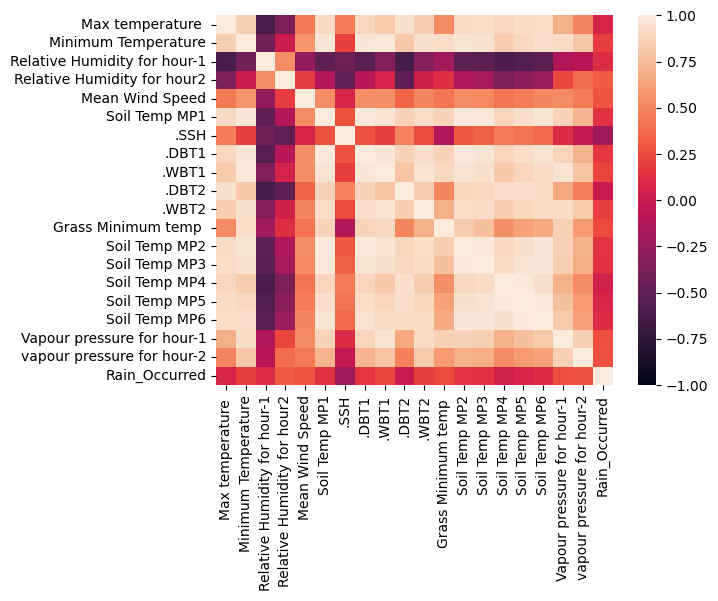

In [7]:
cor1=cor.corr()
sns.heatmap(cor1, vmin=-1,vmax=1)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
import warnings
warnings.filterwarnings("ignore")

# 1. Load data
df = pd.read_csv("hisar_dataset.csv")

print("✅ Loaded dataset")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

# 2. If you have a date column, try to parse it
#    Change "Date" to the exact column name if different
if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    print("\nDate column converted to datetime.")
    print("Date range:", df["Date"].min(), "->", df["Date"].max())
else:
    print("\n(No 'Date' column found – we’ll treat it as purely tabular for now.)")

# 3. Create target columns
#    Assuming the original rainfall column is named exactly "Rain in past (MM)"
df["Rain_Amount"] = df["Rain in past (MM)"]
df["Rain_Occurred"] = (df["Rain_Amount"] > 0).astype(int)

print("\nRainfall Statistics:")
total_days = len(df)
rainy_days = df["Rain_Occurred"].sum()
dry_days = total_days - rainy_days
rainy_pct = rainy_days / total_days * 100
dry_pct = dry_days / total_days * 100

print(f"Total days: {total_days}")
print(f"Rainy days: {rainy_days} ({rainy_pct:.1f}%)")
print(f"Dry days: {dry_days} ({dry_pct:.1f}%)")

# 4. Basic info and missing values
print("\nData types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isna().sum())


✅ Loaded dataset
Shape: (2875, 31)

First 5 rows:
   INDEX  YEAR  WEEK No. (1-52)  DATE  MONTH  .DBT1  .WBT1  .DBT2  .WBT2  \
0  42132  2015                1     1      1    8.0    8.0   21.0   15.4   
1  42132  2015                1     2      1   11.2   11.0   15.8   15.4   
2  42132  2015                1     3      1   12.0   12.0   16.0   14.4   
3  42132  2015                1     4      1    8.4    7.0   13.6   12.6   
4  42132  2015                1     5      1    8.4    8.4   15.8   13.8   

   Max temperature   ...  Relative Humidity for hour2  Mean Wind Speed  \
0              14.0  ...                         52.0              4.8   
1              21.0  ...                         96.0              2.1   
2              16.5  ...                         83.0              4.0   
3              16.0  ...                         89.0              1.2   
4              14.2  ...                         79.0              3.2   

   Wind Direction for hour-1  Wind Direction for

In [11]:
# ---------------------------
# STEP 2: CLEANING DATA
# ---------------------------

df_clean = df.copy()

# 1. Drop completely useless cols
cols_to_drop = ["Unnamed: 27", "Unnamed: 28", "Unnamed: 29", "Unnamed: 30"]
df_clean.drop(columns=cols_to_drop, inplace=True)

# 2. Drop highly missing column
df_clean.drop(columns=["Grass Minimum temp "], inplace=True)

# 3. Create a proper DATE from YEAR, MONTH, DATE
df_clean["DATE_FULL"] = pd.to_datetime(
    df_clean[["YEAR", "MONTH", "DATE"]].rename(
        columns={"YEAR": "year", "MONTH": "month", "DATE": "day"}
    ),
    errors="coerce"
)

print("Date conversion summary:")
print(df_clean["DATE_FULL"].head())

print("\nDate range:")
print(df_clean["DATE_FULL"].min(), " --> ", df_clean["DATE_FULL"].max())

# 4. Fix missing values
#    - Numeric columns: fill median
for col in df_clean.columns:
    if df_clean[col].dtype in ["float64", "int64"]:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("\nMissing values AFTER cleaning:")
print(df_clean.isna().sum())

# 5. Final shape
print("\nFinal cleaned dataset shape:", df_clean.shape)


Date conversion summary:
0   2015-01-01
1   2015-01-02
2   2015-01-03
3   2015-01-04
4   2015-01-05
Name: DATE_FULL, dtype: datetime64[ns]

Date range:
2015-01-01 00:00:00  -->  2022-12-31 00:00:00

Missing values AFTER cleaning:
INDEX                           0
YEAR                            0
WEEK No. (1-52)                 0
DATE                            0
MONTH                           0
.DBT1                           0
.WBT1                           0
.DBT2                           0
.WBT2                           0
Max temperature                 0
Minimum Temperature             0
Soil Temp MP1                   0
Soil Temp MP2                   0
Soil Temp MP3                   0
Soil Temp MP4                   0
Soil Temp MP5                   0
Soil Temp MP6                   0
Vapour pressure for hour-1      0
vapour pressure for hour-2      0
Relative Humidity for hour-1    0
Relative Humidity for hour2     0
Mean Wind Speed                 0
Wind Direction for hou

In [12]:
# ---------------------------
# STEP 3: FEATURE ENGINEERING
# ---------------------------

df_fe = df_clean.copy()

# ---- 1. Sort by date ----
df_fe = df_fe.sort_values("DATE_FULL").reset_index(drop=True)

# ---- 2. Create lag features ----
df_fe["rain_lag1"] = df_fe["Rain_Amount"].shift(1)
df_fe["rain_lag3"] = df_fe["Rain_Amount"].shift(3)

df_fe["rh_lag1"] = df_fe["Relative Humidity for hour-1"].shift(1)
df_fe["temp_lag1"] = df_fe["Max temperature "].shift(1)

# ---- 3. Rolling window features ----
df_fe["rain_roll7"] = df_fe["Rain_Amount"].rolling(7).sum().shift(1)
df_fe["rh_roll3"] = df_fe["Relative Humidity for hour-1"].rolling(3).mean().shift(1)
df_fe["temp_roll7"] = df_fe["Max temperature "].rolling(7).mean().shift(1)

# ---- 4. Cyclical date features ----
df_fe["day_of_year"] = df_fe["DATE_FULL"].dt.dayofyear
df_fe["day_sin"] = np.sin(2 * np.pi * df_fe["day_of_year"] / 365)
df_fe["day_cos"] = np.cos(2 * np.pi * df_fe["day_of_year"] / 365)

# ---- 5. Fill new NaNs created due to shifting ----
df_fe = df_fe.fillna(0)

# ---- 6. Show new columns ----
new_cols = ["rain_lag1", "rain_lag3", "rh_lag1", "temp_lag1",
            "rain_roll7", "rh_roll3", "temp_roll7",
            "day_sin", "day_cos"]

print("New feature columns created:")
for c in new_cols:
    print("-", c)

print("\nFinal shape after feature engineering:", df_fe.shape)
print(df_fe[new_cols].head(10))


New feature columns created:
- rain_lag1
- rain_lag3
- rh_lag1
- temp_lag1
- rain_roll7
- rh_roll3
- temp_roll7
- day_sin
- day_cos

Final shape after feature engineering: (2875, 39)
   rain_lag1  rain_lag3  rh_lag1  temp_lag1  rain_roll7    rh_roll3  \
0        0.0        0.0      0.0        0.0         0.0    0.000000   
1        0.0        0.0    100.0       14.0         0.0    0.000000   
2        0.0        0.0     97.0       21.0         0.0    0.000000   
3        2.6        0.0    100.0       16.5         0.0   99.000000   
4        0.0        0.0     81.0       16.0         0.0   92.666667   
5        0.0        2.6    100.0       14.2         0.0   93.666667   
6        0.0        0.0    100.0       16.7         0.0   93.666667   
7        0.0        0.0    100.0       14.1         2.6  100.000000   
8        0.0        0.0    100.0       13.4         2.6  100.000000   
9        0.0        0.0     97.0       12.9         2.6   99.000000   

   temp_roll7   day_sin   day_cos  

In [16]:
# ---------------------------
# STEP 4: TIME-SERIES SPLIT
# ---------------------------

from sklearn.model_selection import TimeSeriesSplit

df_model = df_fe.copy()

# Define feature set
feature_cols = [
    # Original important features
    "Max temperature ", "Minimum Temperature",
    "Relative Humidity for hour-1", "Relative Humidity for hour2",
    "Vapour pressure for hour-1", "vapour pressure for hour-2",
    "Mean Wind Speed",
    
    # Lags and Rolling
    "rain_lag1", "rain_lag3",
    "rh_lag1", "temp_lag1",
    "rain_roll7", "rh_roll3", "temp_roll7",
    
    # Cyclical
    "day_sin", "day_cos"
]

X = df_model[feature_cols]
y_class = df_model["Rain_Occurred"]       # For classification
y_reg   = df_model["Rain_Amount"]         # For regression

# TIME SERIES SPLIT (5 folds)
tscv = TimeSeriesSplit(n_splits=5)

print("TimeSeriesSplit is ready with 5 folds.")
print("Total samples:", len(df_model))
print(tscv)

TimeSeriesSplit is ready with 5 folds.
Total samples: 2875
TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


In [14]:
# ---------------------------
# STEP 5: TRAIN STAGE-1 CLASSIFIER
# ---------------------------

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt

# Use X, y_class, tscv from previous step
X = X.reset_index(drop=True)
y = y_class.reset_index(drop=True)

# classifier settings
clf_params = {
    "n_estimators": 200,
    "n_jobs": -1,
    "random_state": 42,
    "class_weight": "balanced"   # handles imbalance
}

tscv = TimeSeriesSplit(n_splits=5)
fold = 0

fold_aucs = []
fold_reports = []
fold_confs = []
feature_importances = []

for train_idx, val_idx in tscv.split(X):
    fold += 1
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    clf = RandomForestClassifier(**clf_params)
    clf.fit(X_train, y_train)

    # predictions & probs
    prob = clf.predict_proba(X_val)[:, 1]
    pred = clf.predict(X_val)

    auc = roc_auc_score(y_val, prob)
    acc = accuracy_score(y_val, pred)
    prec, recall, f1, _ = precision_recall_fscore_support(y_val, pred, average="binary", zero_division=0)

    print(f"\n---- Fold {fold} ----")
    print(f"Train samples: {len(train_idx)} | Val samples: {len(val_idx)}")
    print(f"AUC: {auc:.4f} | Acc: {acc:.4f} | Prec: {prec:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")

    print("Confusion Matrix (val):")
    print(confusion_matrix(y_val, pred))

    print("\nClassification Report (val):")
    print(classification_report(y_val, pred, digits=4, zero_division=0))

    fold_aucs.append(auc)
    fold_reports.append(classification_report(y_val, pred, digits=4, output_dict=True))
    fold_confs.append(confusion_matrix(y_val, pred))
    feature_importances.append(clf.feature_importances_)

# Summary across folds
print("\n\n===== SUMMARY =====")
print("Per-fold AUCs:", [round(a,4) for a in fold_aucs])
print("Mean AUC:", np.mean(fold_aucs), "Std AUC:", np.std(fold_aucs))

# Average feature importances (from all folds)
feat_imp_arr = np.mean(np.vstack(feature_importances), axis=0)
feat_imp_df = pd.DataFrame({
    "feature": X.columns,
    "importance": feat_imp_arr
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("\nTop 10 features by average importance:")
print(feat_imp_df.head(10))

# Fit final model on entire dataset (for later use)
final_clf = RandomForestClassifier(**clf_params)
final_clf.fit(X, y)
print("\nFinal classifier trained on full dataset and stored as `final_clf`.")

# Save model (optional) - uncomment if you want to write file
# import joblib
# joblib.dump(final_clf, "rf_rain_classifier.pkl")



---- Fold 1 ----
Train samples: 480 | Val samples: 479
AUC: 0.9409 | Acc: 0.9436 | Prec: 0.9821 | Recall: 0.6790 | F1: 0.8029
Confusion Matrix (val):
[[397   1]
 [ 26  55]]

Classification Report (val):
              precision    recall  f1-score   support

           0     0.9385    0.9975    0.9671       398
           1     0.9821    0.6790    0.8029        81

    accuracy                         0.9436       479
   macro avg     0.9603    0.8382    0.8850       479
weighted avg     0.9459    0.9436    0.9393       479


---- Fold 2 ----
Train samples: 959 | Val samples: 479
AUC: 0.9443 | Acc: 0.9228 | Prec: 0.5660 | Recall: 0.6818 | F1: 0.6186
Confusion Matrix (val):
[[412  23]
 [ 14  30]]

Classification Report (val):
              precision    recall  f1-score   support

           0     0.9671    0.9471    0.9570       435
           1     0.5660    0.6818    0.6186        44

    accuracy                         0.9228       479
   macro avg     0.7666    0.8145    0.7878    

In [18]:
# =========================
# Manual stacking for time-series (no cross_val_predict)
# =========================

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

# Use X, y and tscv from earlier steps (they exist in your notebook)
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)
tscv = TimeSeriesSplit(n_splits=5)

# Define base learners (set n_jobs=1 here to avoid nested parallelism issues)
base_estimators = [
    ("rf", RandomForestClassifier(n_estimators=200, n_jobs=1, random_state=42, class_weight="balanced")),
    ("et", ExtraTreesClassifier(n_estimators=200, n_jobs=1, random_state=42, class_weight="balanced")),
    ("gb", GradientBoostingClassifier(n_estimators=200, random_state=42)),
    ("lr", Pipeline([("scaler", StandardScaler()), ("lr", LogisticRegression(max_iter=200, class_weight="balanced", random_state=42))]))
]

names = [n for n, _ in base_estimators]
print("Base learners:", names)

# ---------- Create OOF predictions for each base model ----------
# oof_preds[name] will be array shape (n_samples,) with predicted probabilities for positive class
oof_preds = {name: np.zeros(len(X)) for name in names}

# We will also collect per-fold metrics for base learners
base_fold_metrics = {name: {"auc": [], "acc": [], "prec": [], "rec": [], "f1": []} for name in names}

for fold, (train_idx, val_idx) in enumerate(tscv.split(X), start=1):
    print(f"\nProcessing fold {fold} / {tscv.get_n_splits()}: train {len(train_idx)} val {len(val_idx)}")
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    for name, estimator in base_estimators:
        # clone estimator to get fresh one for each fold
        from sklearn.base import clone
        est = clone(estimator)
        est.fit(X_train, y_train)
        
        # predicted probability for positive class
        if hasattr(est, "predict_proba"):
            prob = est.predict_proba(X_val)[:, 1]
        else:
            # fallback to decision_function
            if hasattr(est, "decision_function"):
                prob_raw = est.decision_function(X_val)
                prob = (prob_raw - prob_raw.min()) / (prob_raw.max() - prob_raw.min() + 1e-9)
            else:
                # fallback to predict
                prob = est.predict(X_val)
        
        # store OOF predictions
        oof_preds[name][val_idx] = prob
        
        # compute and save fold metrics for this base model
        pred_bin = (prob >= 0.5).astype(int)
        auc = roc_auc_score(y_val, prob)
        acc = accuracy_score(y_val, pred_bin)
        prec = precision_score(y_val, pred_bin, zero_division=0)
        rec = recall_score(y_val, pred_bin, zero_division=0)
        f1 = f1_score(y_val, pred_bin, zero_division=0)
        base_fold_metrics[name]["auc"].append(auc)
        base_fold_metrics[name]["acc"].append(acc)
        base_fold_metrics[name]["prec"].append(prec)
        base_fold_metrics[name]["rec"].append(rec)
        base_fold_metrics[name]["f1"].append(f1)

# ---------- Print mean metrics for each base learner ----------
print("\nBase learners CV metrics (averaged across folds):")
for name in names:
    m = base_fold_metrics[name]
    print(f"{name}: AUC={np.mean(m['auc']):.4f}, Acc={np.mean(m['acc']):.4f}, Prec={np.mean(m['prec']):.4f}, Rec={np.mean(m['rec']):.4f}, F1={np.mean(m['f1']):.4f}")

# ---------- Build meta-features (stacked features) ----------
# Create a DataFrame: each column = OOF probs from a base model
meta_X = pd.DataFrame({name: oof_preds[name] for name in names})
meta_y = y.copy()

print("\nMeta feature shape:", meta_X.shape)
print("Example meta features (head):")
print(meta_X.head())

# ---------- Train meta-learner on OOF predictions ----------
meta_learner = LogisticRegression(max_iter=300)
meta_learner.fit(meta_X, meta_y)
print("\nMeta-learner trained on OOF predictions.")

# Evaluate meta-learner via TimeSeriesSplit as well (using the OOF meta_X)
meta_auc = roc_auc_score(meta_y, meta_learner.predict_proba(meta_X)[:,1])
meta_pred_bin = (meta_learner.predict_proba(meta_X)[:,1] >= 0.5).astype(int)
print("Meta-learner AUC (on OOF meta-features):", meta_auc)
print("Meta-learner Acc (on OOF meta-features):", accuracy_score(meta_y, meta_pred_bin))
print("Meta-learner Recall (on OOF meta-features):", recall_score(meta_y, meta_pred_bin, zero_division=0))

# ---------- Fit final base learners on full data for inference ----------
final_base_models = {}
for name, estimator in base_estimators:
    est = estimator  # fresh estimator
    est.fit(X, y)    # fit on full data
    final_base_models[name] = est

print("\nFinal base models trained on full data.")

# ---------- Inference function for stacked model ----------
def stacked_predict_proba(X_new):
    # X_new: DataFrame with same features
    # get base models' predicted probs
    base_probs = np.column_stack([
        (final_base_models[name].predict_proba(X_new)[:,1] if hasattr(final_base_models[name], "predict_proba")
         else (lambda m: (m.decision_function(X_new) - m.decision_function(X_new).min()) / (m.decision_function(X_new).max() - m.decision_function(X_new).min() + 1e-9))(final_base_models[name]))
        for name in names
    ])
    meta_feats = pd.DataFrame(base_probs, columns=names)
    return meta_learner.predict_proba(meta_feats)[:,1]

# Quick train-AUC for stacked model (on full training set)
probs_stacked_full = stacked_predict_proba(X)
print("\nStacked model AUC on full training set:", roc_auc_score(y, probs_stacked_full))

# Save models if you want (uncomment)
# import joblib
# joblib.dump(final_base_models, "final_base_models_dict.pkl")
# joblib.dump(meta_learner, "meta_learner.pkl")


Base learners: ['rf', 'et', 'gb', 'lr']

Processing fold 1 / 5: train 480 val 479

Processing fold 2 / 5: train 959 val 479

Processing fold 3 / 5: train 1438 val 479

Processing fold 4 / 5: train 1917 val 479

Processing fold 5 / 5: train 2396 val 479

Base learners CV metrics (averaged across folds):
rf: AUC=0.9614, Acc=0.9570, Prec=0.8854, Rec=0.7644, F1=0.8118
et: AUC=0.9701, Acc=0.9570, Prec=0.8845, Rec=0.7687, F1=0.8116
gb: AUC=0.9489, Acc=0.9520, Prec=0.8446, Rec=0.7910, F1=0.8063
lr: AUC=0.8225, Acc=0.7537, Prec=0.3129, Rec=0.7376, F1=0.4375

Meta feature shape: (2875, 4)
Example meta features (head):
    rf   et   gb   lr
0  0.0  0.0  0.0  0.0
1  0.0  0.0  0.0  0.0
2  0.0  0.0  0.0  0.0
3  0.0  0.0  0.0  0.0
4  0.0  0.0  0.0  0.0

Meta-learner trained on OOF predictions.
Meta-learner AUC (on OOF meta-features): 0.921673622386848
Meta-learner Acc (on OOF meta-features): 0.9450434782608695
Meta-learner Recall (on OOF meta-features): 0.6464379947229552

Final base models trained 

In [15]:
# ---------------------------
# STEP 6: TRAIN STAGE-2 REGRESSOR (RAIN AMOUNT)
# ---------------------------

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Keep only rainy days
rain_mask = y_reg > 0
X_rain = X[rain_mask]
y_rain = y_reg[rain_mask]

print("Rainy samples:", len(X_rain))

# TimeSeriesSplit again
tscv = TimeSeriesSplit(n_splits=5)

reg = RandomForestRegressor(
    n_estimators=300,
    n_jobs=-1,
    random_state=42
)

fold = 0
mae_list = []
rmse_list = []
r2_list = []

for train_idx, val_idx in tscv.split(X_rain):
    fold += 1
    X_train, X_val = X_rain.iloc[train_idx], X_rain.iloc[val_idx]
    y_train, y_val = y_rain.iloc[train_idx], y_rain.iloc[val_idx]
    
    reg.fit(X_train, y_train)
    pred = reg.predict(X_val)
    
    mae = mean_absolute_error(y_val, pred)
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    r2 = r2_score(y_val, pred)
    
    mae_list.append(mae)
    rmse_list.append(rmse)
    r2_list.append(r2)
    
    print(f"\n---- Fold {fold} ----")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")

print("\n===== SUMMARY =====")
print("MAE avg:", np.mean(mae_list))
print("RMSE avg:", np.mean(rmse_list))
print("R² avg:", np.mean(r2_list))

# Fit final model
final_reg = RandomForestRegressor(
    n_estimators=300, n_jobs=-1, random_state=42
)
final_reg.fit(X_rain, y_rain)

print("\nFinal regressor trained on rainy days and stored as `final_reg`.")


Rainy samples: 379

---- Fold 1 ----
MAE: 7.0114
RMSE: 11.1297
R²: 0.5261

---- Fold 2 ----
MAE: 8.8545
RMSE: 17.1269
R²: -0.5813

---- Fold 3 ----
MAE: 5.8944
RMSE: 9.3583
R²: 0.3720

---- Fold 4 ----
MAE: 1.5485
RMSE: 2.9581
R²: 0.9491

---- Fold 5 ----
MAE: 1.5465
RMSE: 3.1164
R²: 0.9565

===== SUMMARY =====
MAE avg: 4.971060317460315
RMSE avg: 8.73789905280363
R² avg: 0.4444677669733942

Final regressor trained on rainy days and stored as `final_reg`.


In [19]:
# =========================
# REGRESSION ENSEMBLE WITH XGBoost & LightGBM (TimeSeries-safe manual stacking)
# =========================

import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

# sklearn
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone

# Try to import LightGBM and XGBoost if available
available_optional = {}
try:
    import lightgbm as lgb
    available_optional['lgb'] = True
    print("LightGBM available")
except Exception:
    available_optional['lgb'] = False
    print("LightGBM NOT available — will skip it.")

try:
    import xgboost as xgb
    available_optional['xgb'] = True
    print("XGBoost available")
except Exception:
    available_optional['xgb'] = False
    print("XGBoost NOT available — will skip it.")

# ---------------------------
# Prepare rainy-day data subset (assumes X and y_reg from earlier steps are present)
# ---------------------------
rain_mask = y_reg > 0
X_r = X[rain_mask].reset_index(drop=True)
y_r = y_reg[rain_mask].reset_index(drop=True)

print("\nRainy samples for regression:", len(X_r))

tscv = TimeSeriesSplit(n_splits=5)

# ---------------------------
# Base Regressors (include xgb/lgb if available)
# ---------------------------
base_regressors = [
    ("rf", RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=1)),
    ("et", ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=1)),
    ("gb", GradientBoostingRegressor(n_estimators=300, random_state=42)),
    ("lr", Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())]))
]

if available_optional.get('xgb'):
    base_regressors.append(("xgb", xgb.XGBRegressor(n_estimators=300, random_state=42, n_jobs=1, verbosity=0)))
if available_optional.get('lgb'):
    # use LGBMRegressor with reasonable defaults
    base_regressors.append(("lgb", lgb.LGBMRegressor(n_estimators=300, random_state=42, n_jobs=1)))

names = [name for name, _ in base_regressors]
print("Base regressors to run:", names)

# ---------------------------
# Prepare storage for OOF preds and metrics
# ---------------------------
oof_preds_reg = {name: np.zeros(len(X_r)) for name in names}
reg_metrics = {name: {"mae": [], "rmse": [], "r2": []} for name in names}

# ---------------------------
# Generate OOF predictions using TimeSeriesSplit (no cross_val_predict)
# ---------------------------
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_r), start=1):
    print(f"\n---- Fold {fold} (train {len(train_idx)} val {len(val_idx)}) ----")
    
    X_train, X_val = X_r.iloc[train_idx], X_r.iloc[val_idx]
    y_train, y_val = y_r.iloc[train_idx], y_r.iloc[val_idx]

    for name, model in base_regressors:
        est = clone(model)
        est.fit(X_train, y_train)
        pred = est.predict(X_val)

        # store OOF preds
        oof_preds_reg[name][val_idx] = pred

        # metrics
        mae = mean_absolute_error(y_val, pred)
        rmse = np.sqrt(mean_squared_error(y_val, pred))
        r2 = r2_score(y_val, pred)

        reg_metrics[name]["mae"].append(mae)
        reg_metrics[name]["rmse"].append(rmse)
        reg_metrics[name]["r2"].append(r2)

        print(f"{name:>4} -> MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}")

# ---------------------------
# Average Base Model Metrics
# ---------------------------
print("\n==== BASE MODEL PERFORMANCE (avg across folds) ====")
for name in names:
    m = reg_metrics[name]
    print(f"{name:>4}: MAE={np.mean(m['mae']):.3f}, RMSE={np.mean(m['rmse']):.3f}, R2={np.mean(m['r2']):.3f}")

# ---------------------------
# Build meta-features for regression (OOF predictions)
# ---------------------------
meta_X_reg = pd.DataFrame({name: oof_preds_reg[name] for name in names})
meta_y_reg = y_r.copy()

print("\nMeta features created:", meta_X_reg.shape)
print(meta_X_reg.head())

# ---------------------------
# Meta-Learner (Ridge to reduce overfitting)
# ---------------------------
meta_regressor = Ridge(alpha=1.0)
meta_regressor.fit(meta_X_reg, meta_y_reg)

meta_pred = meta_regressor.predict(meta_X_reg)
meta_mae = mean_absolute_error(meta_y_reg, meta_pred)
meta_rmse = np.sqrt(mean_squared_error(meta_y_reg, meta_pred))
meta_r2 = r2_score(meta_y_reg, meta_pred)

print("\n===== META-REGRESSOR PERFORMANCE ON OOF FEATURES =====")
print(f"MAE: {meta_mae:.3f}")
print(f"RMSE: {meta_rmse:.3f}")
print(f"R²: {meta_r2:.3f}")

# ---------------------------
# Train final base regressors on FULL rainy-only dataset
# ---------------------------
final_regressors = {}
for name, model in base_regressors:
    est = model
    est.fit(X_r, y_r)
    final_regressors[name] = est

print("\nFinal base regressors trained on full rainy dataset.")

# ---------------------------
# Inference function for stacked regression
# ---------------------------
def stacked_regression_predict(X_new):
    """Predict rainfall amount using stacked regression (expects same features as X_r)."""
    base_preds = []
    for name in names:
        base_pred = final_regressors[name].predict(X_new)
        base_preds.append(base_pred)
    meta_features = np.column_stack(base_preds)
    final_pred = meta_regressor.predict(meta_features)
    return final_pred

print("\nStacked regression model ready for inference.")


LightGBM NOT available — will skip it.
XGBoost available

Rainy samples for regression: 379
Base regressors to run: ['rf', 'et', 'gb', 'lr', 'xgb']

---- Fold 1 (train 64 val 63) ----
  rf -> MAE: 7.011, RMSE: 11.130, R2: 0.526
  et -> MAE: 4.791, RMSE: 8.923, R2: 0.695
  gb -> MAE: 4.188, RMSE: 8.916, R2: 0.696
  lr -> MAE: 11.738, RMSE: 16.518, R2: -0.044
 xgb -> MAE: 4.807, RMSE: 10.449, R2: 0.582

---- Fold 2 (train 127 val 63) ----
  rf -> MAE: 8.854, RMSE: 17.127, R2: -0.581
  et -> MAE: 7.618, RMSE: 14.236, R2: -0.092
  gb -> MAE: 8.667, RMSE: 17.793, R2: -0.707
  lr -> MAE: 10.887, RMSE: 15.766, R2: -0.340
 xgb -> MAE: 9.387, RMSE: 19.486, R2: -1.047

---- Fold 3 (train 190 val 63) ----
  rf -> MAE: 5.894, RMSE: 9.358, R2: 0.372
  et -> MAE: 4.938, RMSE: 8.563, R2: 0.474
  gb -> MAE: 4.986, RMSE: 10.061, R2: 0.274
  lr -> MAE: 10.195, RMSE: 12.180, R2: -0.064
 xgb -> MAE: 5.217, RMSE: 11.399, R2: 0.068

---- Fold 4 (train 253 val 63) ----
  rf -> MAE: 1.548, RMSE: 2.958, R2: 0.

In [22]:
# =========================
# STEP Q1: Prepare rainy-only data
# =========================

import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_pinball_loss

# Make sure X and y_reg are defined from previous steps
# X = df_model[feature_cols]
# y_reg = df_model["Rain_Amount"]

rain_mask = y_reg > 0
X_r = X[rain_mask].reset_index(drop=True)
y_r = y_reg[rain_mask].reset_index(drop=True)

print("Rainy samples:", len(X_r))
print("\nRain amount stats (mm):")
print(y_r.describe())

# Define quantile levels we want to model
quantiles = [0.1, 0.5, 0.9]
print("\nQuantiles to model:", quantiles)


Rainy samples: 379

Rain amount stats (mm):
count    379.000000
mean       9.086016
std       14.278944
min        0.100000
25%        1.200000
50%        3.500000
75%        9.000000
max      100.600000
Name: Rain_Amount, dtype: float64

Quantiles to model: [0.1, 0.5, 0.9]


In [23]:
# =========================
# STEP Q2: Train Quantile Models with TimeSeriesSplit
# =========================

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_pinball_loss

tscv = TimeSeriesSplit(n_splits=5)

quantile_models = {}   # store trained models
quantile_results = {}  # store metrics

for q in quantiles:
    print(f"\n==============================")
    print(f" Training Quantile: {q}")
    print(f"==============================\n")
    
    # Define model
    q_model = GradientBoostingRegressor(
        loss="quantile",
        alpha=q,                # quantile
        learning_rate=0.03,
        n_estimators=500,
        max_depth=3,
        min_samples_leaf=5,
        random_state=42
    )
    
    # To store metrics across folds
    fold_mae, fold_rmse, fold_r2, fold_pbl = [], [], [], []
    
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_r), start=1):
        X_train, X_val = X_r.iloc[train_idx], X_r.iloc[val_idx]
        y_train, y_val = y_r.iloc[train_idx], y_r.iloc[val_idx]
        
        # Fit model on training fold
        q_model.fit(X_train, y_train)
        
        # Predictions
        y_pred = q_model.predict(X_val)
        
        # Metrics
        mae = mean_absolute_error(y_val, y_pred)
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        r2 = r2_score(y_val, y_pred)
        pbl = mean_pinball_loss(y_val, y_pred, alpha=q)
        
        fold_mae.append(mae)
        fold_rmse.append(rmse)
        fold_r2.append(r2)
        fold_pbl.append(pbl)
        
        print(f"Fold {fold} -> MAE={mae:.3f}, RMSE={rmse:.3f}, R²={r2:.3f}, Pinball={pbl:.3f}")
    
    # Store results
    quantile_results[q] = {
        "MAE": np.mean(fold_mae),
        "RMSE": np.mean(fold_rmse),
        "R2": np.mean(fold_r2),
        "Pinball": np.mean(fold_pbl)
    }
    
    # Fit final model on full rainy dataset
    q_model.fit(X_r, y_r)
    quantile_models[q] = q_model

# Display summary
print("\n===== QUANTILE MODEL PERFORMANCE (AVG ACROSS FOLDS) =====")
for q in quantile_results:
    print(f"Quantile {q}: {quantile_results[q]}")



 Training Quantile: 0.1

Fold 1 -> MAE=9.835, RMSE=18.617, R²=-0.326, Pinball=1.123
Fold 2 -> MAE=5.633, RMSE=14.428, R²=-0.122, Pinball=0.756
Fold 3 -> MAE=6.968, RMSE=13.565, R²=-0.320, Pinball=0.722
Fold 4 -> MAE=6.390, RMSE=14.498, R²=-0.222, Pinball=0.642
Fold 5 -> MAE=10.347, RMSE=18.055, R²=-0.462, Pinball=1.043

 Training Quantile: 0.5

Fold 1 -> MAE=6.020, RMSE=12.507, R²=0.402, Pinball=3.010
Fold 2 -> MAE=6.345, RMSE=13.371, R²=0.036, Pinball=3.172
Fold 3 -> MAE=5.242, RMSE=9.568, R²=0.343, Pinball=2.621
Fold 4 -> MAE=2.927, RMSE=10.427, R²=0.368, Pinball=1.464
Fold 5 -> MAE=4.577, RMSE=11.402, R²=0.417, Pinball=2.289

 Training Quantile: 0.9

Fold 1 -> MAE=9.702, RMSE=14.684, R²=0.175, Pinball=2.492
Fold 2 -> MAE=14.341, RMSE=21.034, R²=-1.385, Pinball=2.637
Fold 3 -> MAE=13.940, RMSE=18.306, R²=-1.403, Pinball=2.206
Fold 4 -> MAE=8.646, RMSE=14.657, R²=-0.249, Pinball=0.877
Fold 5 -> MAE=6.096, RMSE=8.954, R²=0.641, Pinball=0.679

===== QUANTILE MODEL PERFORMANCE (AVG ACRO

In [26]:
# ---------------------------
# FIXED predict_rainfall() — aligns feature names with trained quantile models
# ---------------------------

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# Helper: get median values from training X if available, else zeros
try:
    train_feature_medians = X.median()  # X should be your training-feature DataFrame from before
    train_feature_medians = train_feature_medians.to_dict()
except Exception:
    train_feature_medians = {}

# Determine expected feature names for quantile models (prefer q=0.5 model as reference)
if 'quantile_models' in globals() and 0.5 in quantile_models:
    ref_model = quantile_models[0.5]
    try:
        expected_features = list(ref_model.feature_names_in_)
    except Exception:
        # fallback to the model_feature_cols we used earlier
        expected_features = [
            "Max temperature ", "Minimum Temperature",
            "Relative Humidity for hour-1", "Relative Humidity for hour2",
            "Vapour pressure for hour-1", "vapour pressure for hour-2",
            "Mean Wind Speed",
            "rain_lag1", "rain_lag3",
            "rh_lag1", "temp_lag1",
            "rain_roll7", "rh_roll3", "temp_roll7",
            "day_sin", "day_cos"
        ]
else:
    # If quantile_models not present, still set expected_features to our feature list
    expected_features = [
        "Max temperature ", "Minimum Temperature",
        "Relative Humidity for hour-1", "Relative Humidity for hour2",
        "Vapour pressure for hour-1", "vapour pressure for hour-2",
        "Mean Wind Speed",
        "rain_lag1", "rain_lag3",
        "rh_lag1", "temp_lag1",
        "rain_roll7", "rh_roll3", "temp_roll7",
        "day_sin", "day_cos"
    ]

def _align_features_for_predict(X_new):
    """
    Return X_pred DataFrame containing exactly expected_features (in same order).
    Missing columns are filled with training medians (or zeros).
    Extra columns are dropped.
    """
    Xp = X_new.copy()
    # ensure all expected_features present
    for f in expected_features:
        if f not in Xp.columns:
            # fill with median from training if available, else 0
            Xp[f] = train_feature_medians.get(f, 0.0)
    # drop extras
    Xp = Xp[expected_features].copy()
    # ensure numeric dtype
    for c in Xp.columns:
        if not np.issubdtype(Xp[c].dtype, np.number):
            Xp[c] = pd.to_numeric(Xp[c], errors='coerce').fillna(train_feature_medians.get(c, 0.0))
    return Xp

# Re-define predict_rainfall to use aligned features
def predict_rainfall(df_input, hist_df=None, prob_threshold=0.5):
    # prepare features (robust prepare_features function should exist)
    if "prepare_features_for_model" in globals():
        X_new_full = prepare_features_for_model(df_input.copy(), full_df_for_lags=hist_df)
    else:
        # fallback: assume df_input already has the engineered cols
        X_new_full = df_input.copy()
    
    # compute classifier probability (use stacked_predict_proba or fallbacks)
    prob_rain = None
    if "stacked_predict_proba" in globals():
        try:
            prob_rain = stacked_predict_proba(_align_features_for_predict(X_new_full))  # classifier expects same features as used earlier
        except Exception:
            prob_rain = None
    if prob_rain is None and "final_stack_clf" in globals():
        try:
            prob_rain = final_stack_clf.predict_proba(_align_features_for_predict(X_new_full))[:,1]
        except Exception:
            prob_rain = None
    if prob_rain is None and "final_clf" in globals():
        try:
            prob_rain = final_clf.predict_proba(_align_features_for_predict(X_new_full))[:,1]
        except Exception:
            prob_rain = None
    if prob_rain is None:
        # fallback rule
        prob_rain = ( (X_new_full.get("rain_roll7", 0) > 0) | (X_new_full.get("rh_lag1", 0) > 80) ).astype(float) * 0.6
        prob_rain = np.asarray(prob_rain)
    
    # Ensure quantile models exist
    if 'quantile_models' not in globals():
        raise RuntimeError("quantile_models not found — run quantile training step first.")
    
    # Align features to expected features for regressors
    X_for_reg = _align_features_for_predict(X_new_full)
    
    # Predict quantiles using aligned features
    pred_q10 = quantile_models[0.1].predict(X_for_reg)
    pred_q50 = quantile_models[0.5].predict(X_for_reg)
    pred_q90 = quantile_models[0.9].predict(X_for_reg)
    
    pred_q10 = np.clip(np.asarray(pred_q10).astype(float), 0, None)
    pred_q50 = np.clip(np.asarray(pred_q50).astype(float), 0, None)
    pred_q90 = np.clip(np.asarray(pred_q90).astype(float), 0, None)
    
    expected_rain = prob_rain * pred_q50
    binary_pred = (prob_rain >= prob_threshold).astype(int)
    amount_if_rain = pred_q50 * binary_pred
    
    out = df_input.copy().reset_index(drop=True)
    out["prob_rain"] = prob_rain
    out["pred_q10_mm"] = pred_q10
    out["pred_median_q50_mm"] = pred_q50
    out["pred_q90_mm"] = pred_q90
    out["expected_rain_mm"] = expected_rain
    out["binary_rain_pred"] = binary_pred
    out["amount_if_rain_mm"] = amount_if_rain
    
    # attach dew_point/vpd if they exist in X_new_full
    if "dew_point" in X_new_full.columns:
        out["dew_point_C"] = X_new_full["dew_point"].values
    if "vpd" in X_new_full.columns:
        out["vpd_kpa"] = X_new_full["vpd"].values
    
    return out

# ---- Demo run (last 10 rows of df_fe) ----
try:
    sample_in = df_fe.tail(10).copy()
    preds_demo = predict_rainfall(sample_in, hist_df=df_fe)
    display_cols = ["DATE_FULL","prob_rain","pred_median_q50_mm","pred_q10_mm","pred_q90_mm","expected_rain_mm","binary_rain_pred","amount_if_rain_mm"]
    if "DATE_FULL" in preds_demo.columns:
        print(preds_demo[display_cols])
    else:
        print(preds_demo[display_cols].head(10))
except Exception as e:
    print("Demo failed. Error:", e)
    print("If df_fe is not present, call predict_rainfall(new_df, hist_df=your_history_df).")


             DATE_FULL  prob_rain  pred_median_q50_mm  pred_q10_mm  \
0  2022-12-23 00:00:00      0.000            9.624094     0.918119   
1  2022-12-24 00:00:00      0.005            9.639456     0.918119   
2  2022-12-25 00:00:00      0.000            4.994167     0.917870   
3  2022-12-26 00:00:00      0.000            4.977187     0.917870   
4  2022-12-27 00:00:00      0.000            9.617193     0.969621   
5  2022-12-28 00:00:00      0.000            9.618459     0.969621   
6  2022-12-29 00:00:00      0.000            9.616488     0.969621   
7  2022-12-30 00:00:00      0.000            9.611324     0.969621   
8  2022-12-31 00:00:00      0.000            9.441052     0.718821   
9                    0      0.000            9.400121     0.718821   

   pred_q90_mm  expected_rain_mm  binary_rain_pred  amount_if_rain_mm  
0    15.457958          0.000000                 0                0.0  
1    15.457958          0.048197                 0                0.0  
2    14.55674

In [27]:
# =========================
# STEP Q4: Evaluate full system on historical data
# =========================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
)

# 1) Get predictions for ALL days in history
full_preds = predict_rainfall(df_fe, hist_df=df_fe)

# Make sure we align true targets
y_true_class = df_fe["Rain_Occurred"].values
y_true_amount = df_fe["Rain_Amount"].values

y_pred_class = full_preds["binary_rain_pred"].values
y_prob_rain  = full_preds["prob_rain"].values

q10 = full_preds["pred_q10_mm"].values
q50 = full_preds["pred_median_q50_mm"].values
q90 = full_preds["pred_q90_mm"].values

# 2) CLASSIFICATION METRICS (rain / no-rain)
acc  = accuracy_score(y_true_class, y_pred_class)
prec = precision_score(y_true_class, y_pred_class, zero_division=0)
rec  = recall_score(y_true_class, y_pred_class, zero_division=0)
f1   = f1_score(y_true_class, y_pred_class, zero_division=0)
auc  = roc_auc_score(y_true_class, y_prob_rain)

print("=== CLASSIFICATION (Rain Occurred) ===")
print("Accuracy :", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall   :", round(rec, 4))
print("F1-score :", round(f1, 4))
print("ROC AUC  :", round(auc, 4))
print("Confusion Matrix:")
print(confusion_matrix(y_true_class, y_pred_class))


# 3) REGRESSION METRICS on RAINY DAYS ONLY (amount)
rain_mask = y_true_amount > 0
y_true_rain = y_true_amount[rain_mask]
q50_rain    = q50[rain_mask]

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae_rain  = mean_absolute_error(y_true_rain, q50_rain)
rmse_rain = np.sqrt(mean_squared_error(y_true_rain, q50_rain))
r2_rain   = r2_score(y_true_rain, q50_rain)

print("\n=== REGRESSION (Rain Amount, rainy days only) ===")
print("MAE  :", round(mae_rain, 4))
print("RMSE :", round(rmse_rain, 4))
print("R²   :", round(r2_rain, 4))


# 4) INTERVAL COVERAGE (q10–q90)
inside = (y_true_rain >= q10[rain_mask]) & (y_true_rain <= q90[rain_mask])
coverage = inside.mean()

too_low  = (y_true_rain < q10[rain_mask]).mean()
too_high = (y_true_rain > q90[rain_mask]).mean()

print("\n=== PREDICTION INTERVAL COVERAGE (on rainy days) ===")
print("Fraction inside [q10, q90]:", round(coverage, 3))
print("Fraction below q10        :", round(too_low, 3))
print("Fraction above q90        :", round(too_high, 3))


=== CLASSIFICATION (Rain Occurred) ===
Accuracy : 0.7843
Precision: 0.1269
Recall   : 0.1082
F1-score : 0.1168
ROC AUC  : 0.4606
Confusion Matrix:
[[2214  282]
 [ 338   41]]

=== REGRESSION (Rain Amount, rainy days only) ===
MAE  : 9.8589
RMSE : 16.1095
R²   : -0.2762

=== PREDICTION INTERVAL COVERAGE (on rainy days) ===
Fraction inside [q10, q90]: 0.599
Fraction below q10        : 0.198
Fraction above q90        : 0.203
